### 1. Import Required Libraries

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random 
import os

### 2. Configuration Parameters

In [2]:
DATA_ROOT   = './data'
NUM_CLASSES = 10
IMG_SIZE    = 32 
IN_CHANNELS = 1      # MNIST is grayscale. 
BATCH_SIZE  = 64
EPOCHS      = 5
LR          = 1e-3
SEED        = 42
CHECKPOINT  = 'checkpoints/best_model.pth'

# Set environment for reproducibility and hardware acceleration
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
os.makedirs('checkpoints', exist_ok=True)
print(f"Device: {device}")

Device: cuda


### 3. Data Preparation

In [3]:
# Transformation pipeline
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Load datasets
train_dataset = datasets.MNIST(root=DATA_ROOT, train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root=DATA_ROOT, train=False, download=True, transform=transform)

# Data Loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

### 4. Data Visualization

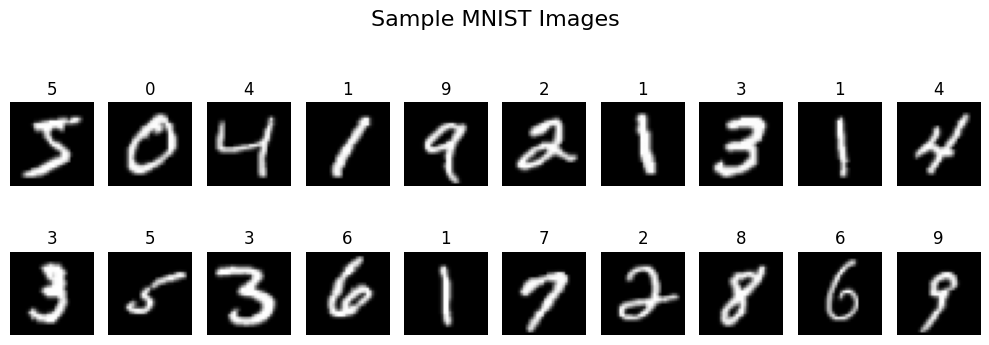

In [4]:
def show_sample(dataset, n=20):
    plt.figure(figsize=(10, 4)) 
    for i in range(n):
        image, label = dataset[i]
        plt.subplot(2, n // 2, i + 1)
        # .squeeze() removes the channel dimension (1, 28, 28) -> (28, 28)
        plt.imshow(image.squeeze(), cmap='gray')
        plt.title(label)
        plt.axis('off')
    
    plt.suptitle("Sample MNIST Images", fontsize=16)
    plt.tight_layout()
    plt.show()

show_sample(train_dataset, n=20)

### 5. Exploratory Data Analysis (EDA)

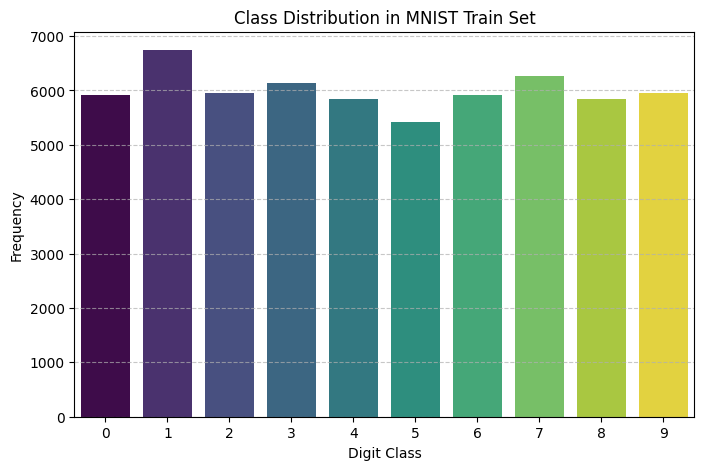

In [5]:
# Extract all labels from the dataset
labels = [label for _, label in train_dataset]

# Create a count plot
plt.figure(figsize=(8, 5))
sns.countplot(x=labels, palette='viridis', hue=labels , legend=False)
plt.title("Class Distribution in MNIST Train Set")
plt.xlabel("Digit Class")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 6. Model Architecture and Initialization

In [6]:
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        # Conv layers
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)    
        
        # Linear layers: 
        # For 32x32 input, after two pools (32->16->8), the feature map is 32 channels * 8 * 8
        self.fc1 = nn.Linear(32 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 10)
        
    def forward(self, x):
        # Layer 1
        x = self.pool(torch.relu(self.conv1(x)))
        # Layer 2
        x = self.pool(torch.relu(self.conv2(x)))
        # Flatten: -1 preserves batch size
        x = x.view(-1, 32 * 8 * 8)
        # Fully connected layers
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x
        
# Create the model instance and move to the device defined in your Config
model = CNNModel().to(device)

### 7. Loss Function and Optimizer

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

### 8. Training Loop Implementation

In [8]:
train_losses = [] 

model.train() # Set model to training mode

for epoch in range(EPOCHS):
    running_loss = 0.0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        # 1. Forward Pass
        optimizer.zero_grad() 
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # 2. Backward Pass & Optimize
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    # Calculate average loss for the epoch
    avg_loss = running_loss / len(train_loader) 
    train_losses.append(avg_loss) 
    
    print(f"Epoch [{epoch + 1} / {EPOCHS}], Loss: {avg_loss:.4f}")

print("Training finished!")

Epoch [1 / 5], Loss: 0.1601
Epoch [2 / 5], Loss: 0.0487
Epoch [3 / 5], Loss: 0.0331
Epoch [4 / 5], Loss: 0.0254
Epoch [5 / 5], Loss: 0.0188
Training finished!


### 9. Plot Training Loss

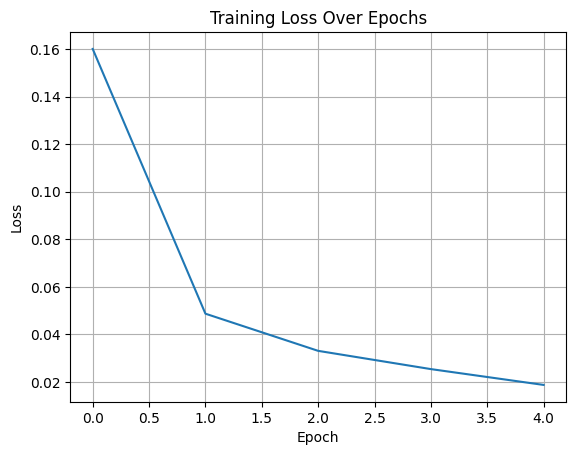

In [9]:
# ... Plot Training Loss ...
plt.plot(train_losses)
plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

### 10. Evaluation

In [10]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

### 11. Confusion Matrix

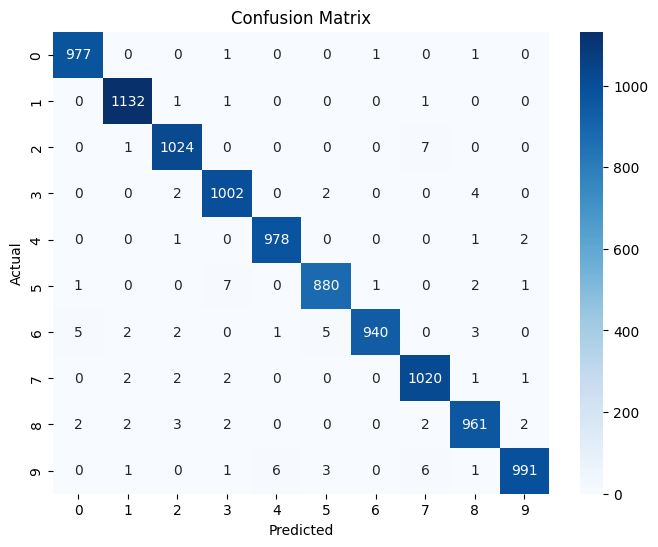

In [11]:
conf_matrix = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="Blues", xticklabels=range(10), yticklabels=range(10))
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### 12. Inference on One Image

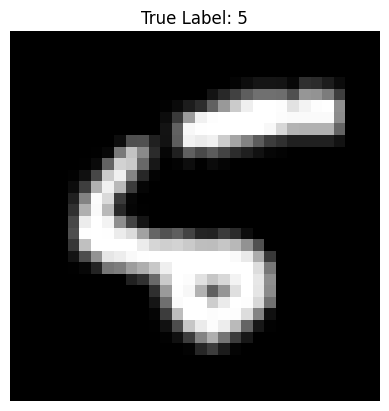

Predicted Class: 5


In [12]:
sample_img, sample_label = test_dataset[8]

plt.imshow(sample_img.squeeze(), cmap='gray')
plt.title(f"True Label: {sample_label}")
plt.axis('off')
plt.show()

sample_tensor = sample_img.unsqueeze(0).to(device)

model.eval()

with torch.no_grad():
    output = model(sample_tensor)
    predicted_class = torch.argmax(output, dim=1).item()

print(f"Predicted Class: {predicted_class}")